# 📡 Prédiction du Désabonnement Client — Customer Churn Prediction
## Notebook Final — Démarche Complète & Analyse Comparative

---

| Projet | Customer Churn Prediction |
|---|---|
| **Dataset** | Telco Customer Churn (IBM Watson Analytics) |
| **Objectif** | Prédire si un client va quitter l'entreprise |
| **Modèles testés** | Régression Logistique · Random Forest · XGBoost · ANN |
| **Modèle retenu** | XGBoost |

---

## 📋 Table des Matières

1. [Contexte & Problématique Métier](#1)
2. [Présentation du Dataset](#2)
3. [Analyse Exploratoire des Données (EDA)](#3)
4. [Pipeline de Prétraitement](#4)
5. [Modèles de Machine Learning](#5)
   - 5.1 Régression Logistique
   - 5.2 Random Forest
   - 5.3 XGBoost
   - 5.4 Optimisation des Hyperparamètres
6. [Deep Learning — Réseau de Neurones (ANN)](#6)
7. [Analyse Comparative des Modèles](#7)
8. [Conclusion & Recommandations](#8)


<a id='1'></a>
---
# 1. 💼 Contexte & Problématique Métier

## Le Churn : un enjeu stratégique majeur

Le **désabonnement client** (*Customer Churn*) désigne le phénomène par lequel des clients cessent d'utiliser les services d'une entreprise sur une période donnée. Dans le secteur des **télécommunications**, ce phénomène représente un défi économique considérable :

- 📉 **Coût d'acquisition** : Acquérir un nouveau client coûte **5 à 7× plus cher** que de fidéliser un client existant
- 💸 **Impact financier** : Un taux de churn de 1% peut représenter des millions d'euros de pertes annuelles
- 🎯 **Potentiel de rétention** : Réduire le churn de seulement 5% peut augmenter les profits de 25 à 95%

## Objectif du Projet

Développer un modèle de **Machine Learning** capable de :

| Objectif | Description |
|---|---|
| 🔍 **Identifier** | Détecter les clients à risque de désabonnement **avant** qu'ils ne partent |
| 📊 **Analyser** | Comprendre les **facteurs** qui déclenchent le churn |
| 💡 **Recommander** | Fournir des insights actionnables pour les équipes de **rétention** |

## Approche Adoptée

```
Données brutes → EDA → Prétraitement → Modélisation ML/DL → Évaluation → Modèle Final
```


<a id='2'></a>
---
# 2. 📊 Présentation du Dataset

Le dataset **Telco Customer Churn** (IBM Watson Analytics) contient des informations sur les clients d'une société de télécommunications et leur statut de désabonnement.

| Caractéristique | Valeur |
|---|---|
| **Source** | IBM Watson Analytics / Kaggle |
| **Nombre de clients** | 7 043 lignes |
| **Nombre de variables** | 21 colonnes |
| **Variable cible** | `Churn` (Yes = client parti, No = client resté) |
| **Taux de churn** | ~26.5% |

### Description des Variables

| Catégorie | Variables |
|---|---|
| **Identifiant** | `customerID` |
| **Démographie** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Services** | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Contrat & Paiement** | `Contract`, `PaperlessBilling`, `PaymentMethod` |
| **Facturation** | `MonthlyCharges`, `TotalCharges`, `tenure` |
| **Cible** | `Churn` |


In [1]:
# Importation de toutes les bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
import joblib

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Bibliothèques chargées avec succès')

✅ Bibliothèques chargées avec succès


In [2]:
# Chargement du dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dimensions du dataset : {df.shape}')
print(f'Taux de churn : {df["Churn"].value_counts(normalize=True)["Yes"]:.1%}')
df.head()

Dimensions du dataset : (7043, 21)
Taux de churn : 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Aperçu global du dataset
print('=== Informations générales ===')
df.info()
print('\n=== Statistiques descriptives ===')
df.describe()

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


<a id='3'></a>
---
# 3. 🔍 Analyse Exploratoire des Données (EDA)

> L'EDA est une étape fondamentale qui permet de **comprendre les données** avant toute modélisation. Elle guide les choix de prétraitement et de feature engineering.


## 3.1 — Analyse de la Variable Cible : `Churn`

Nous analysons d'abord la **distribution de la variable cible** pour détecter un éventuel déséquilibre des classes.


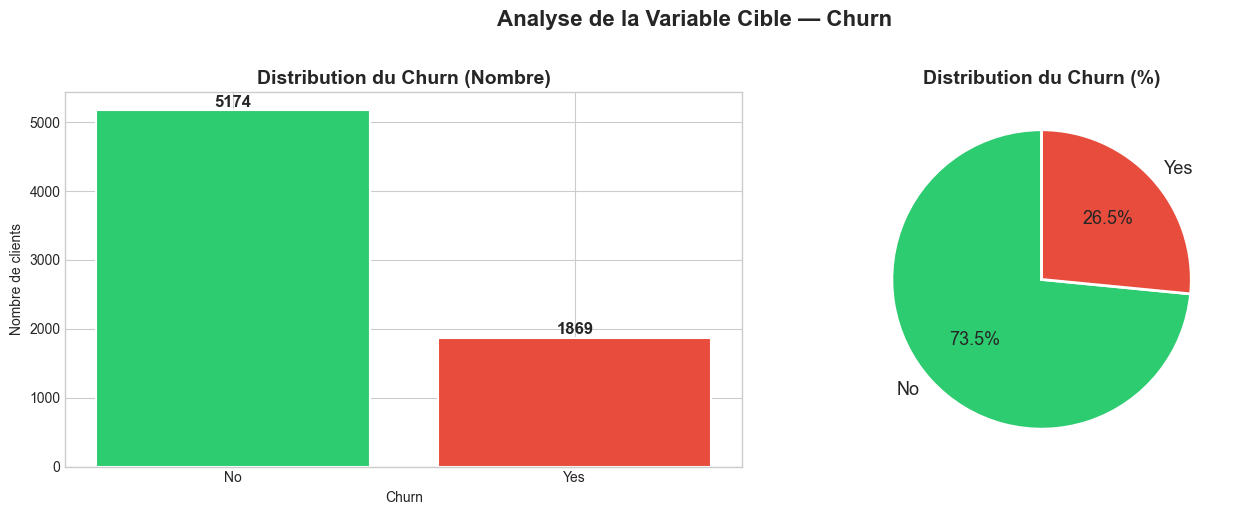

Clients non-churn (No)  : 5,174 (73.5%)
Clients churné  (Yes) : 1,869 (26.5%)

⚠️  Déséquilibre des classes : ratio 2.8:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution absolue
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution du Churn (Nombre)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Nombre de clients')
for i, (label, val) in enumerate(churn_counts.items()):
    axes[0].text(i, val + 50, str(val), ha='center', fontweight='bold', fontsize=12)

# Distribution en pourcentage
churn_pct = df['Churn'].value_counts(normalize=True) * 100
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
axes[1].pie(churn_pct, labels=churn_pct.index, autopct='%1.1f%%',
            colors=colors, wedgeprops=wedge_props, startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('Distribution du Churn (%)', fontsize=14, fontweight='bold')

plt.suptitle('Analyse de la Variable Cible — Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Clients non-churn (No)  : {churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)')
print(f'Clients churné  (Yes) : {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')
print(f'\n⚠️  Déséquilibre des classes : ratio {churn_counts["No"]/churn_counts["Yes"]:.1f}:1')

**Observation :** Le dataset est **déséquilibré** avec ~73% de clients non-churn contre ~27% de churners. Ce déséquilibre impose l'utilisation de métriques adaptées (**Recall**, **ROC-AUC**, **F1-Score**) plutôt que la simple Accuracy.


## 3.2 — Analyse des Variables Numériques

Nous étudions les trois variables numériques continues : `tenure`, `MonthlyCharges` et `TotalCharges`.


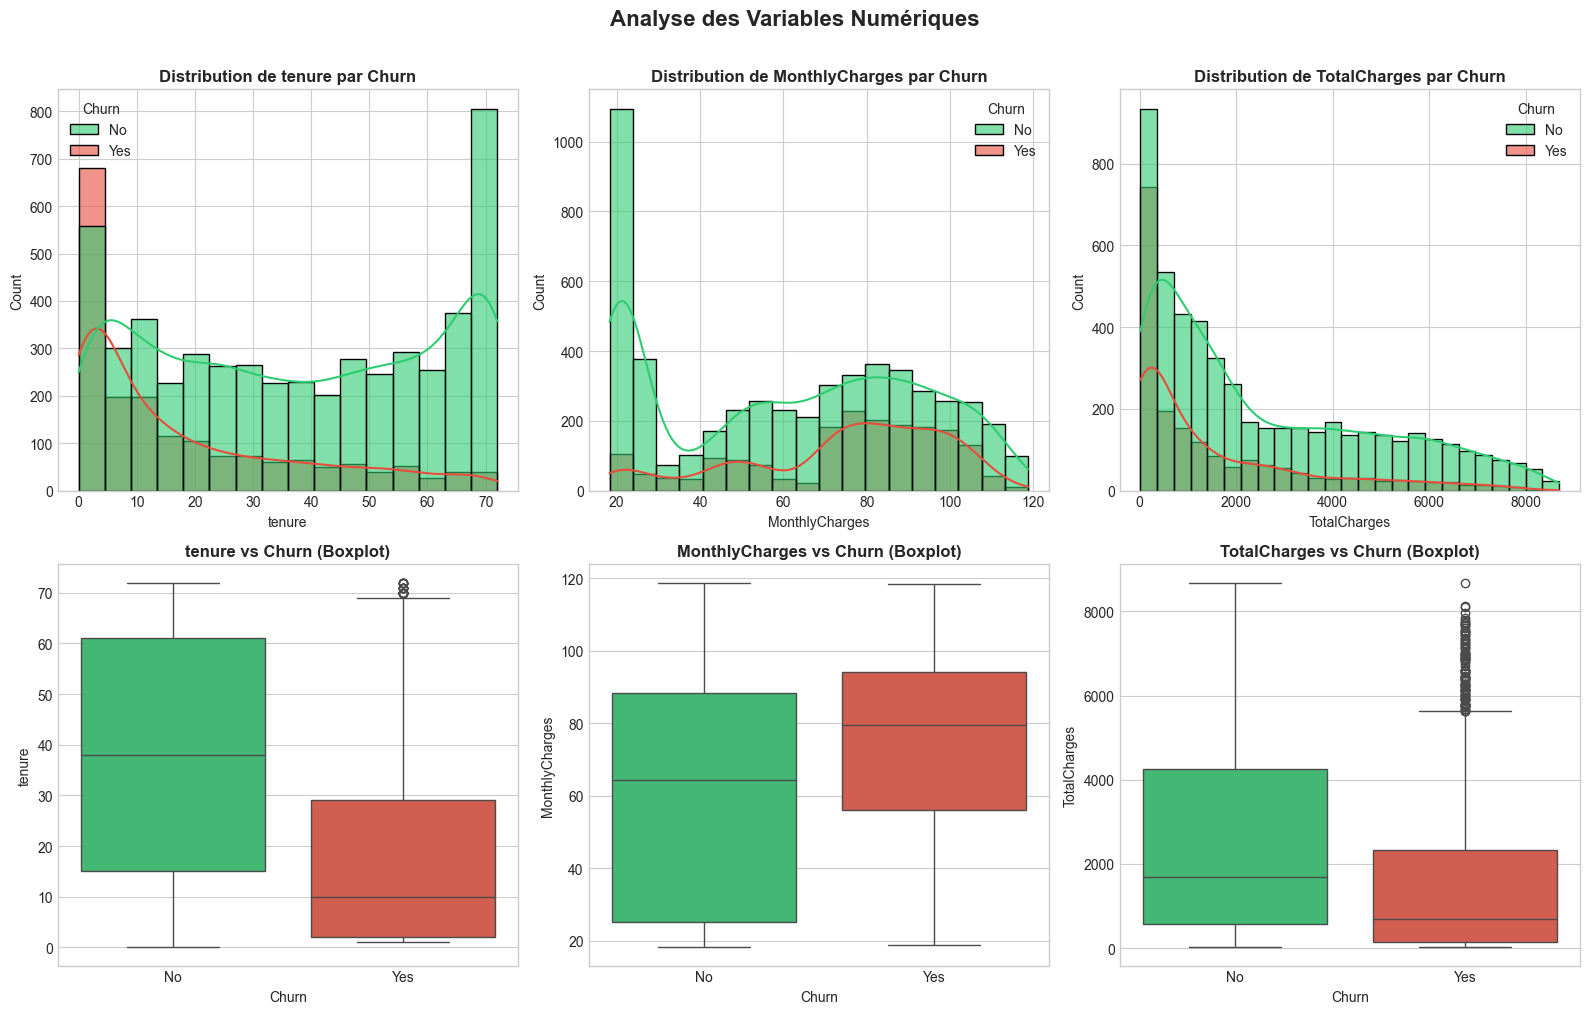

=== Moyennes par groupe Churn ===
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2555.34
Yes     17.98           74.44       1531.80


In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# TotalCharges contient des espaces vides → conversion forcée
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(num_cols):
    # Histogramme
    ax = axes[0, i]
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax,
                 palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, alpha=0.6)
    ax.set_title(f'Distribution de {col} par Churn', fontweight='bold')
    ax.set_xlabel(col)

    # Boxplot
    ax2 = axes[1, i]
    sns.boxplot(data=df, x='Churn', y=col, ax=ax2,
                palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
    ax2.set_title(f'{col} vs Churn (Boxplot)', fontweight='bold')

plt.suptitle('Analyse des Variables Numériques', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Statistiques comparatives
print('=== Moyennes par groupe Churn ===')
print(df.groupby('Churn')[num_cols].mean().round(2))

## 3.3 — Analyse des Variables Catégorielles Clés


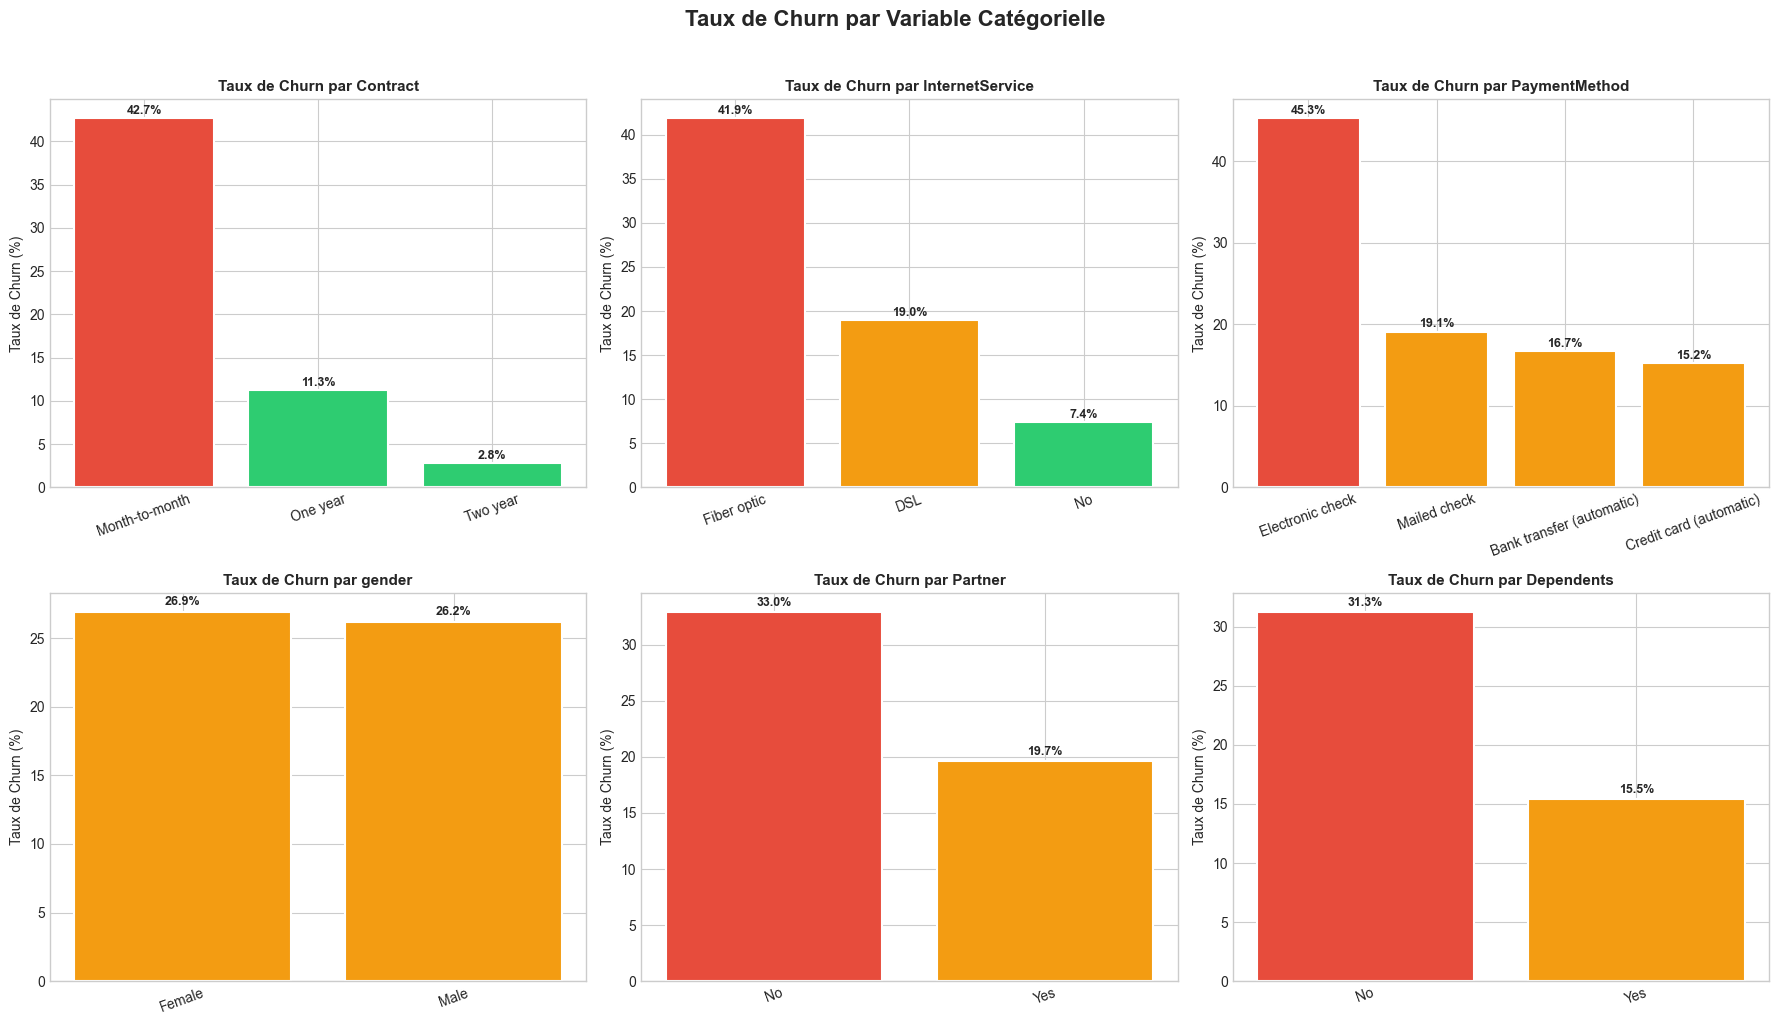

In [6]:
key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)

    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=['#e74c3c' if v > 30 else '#f39c12' if v > 15 else '#2ecc71'
                              for v in churn_rate.values],
                       edgecolor='white', linewidth=1.5)
    axes[i].set_title(f'Taux de Churn par {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Taux de Churn (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Taux de Churn par Variable Catégorielle', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3.4 — Matrice de Corrélation


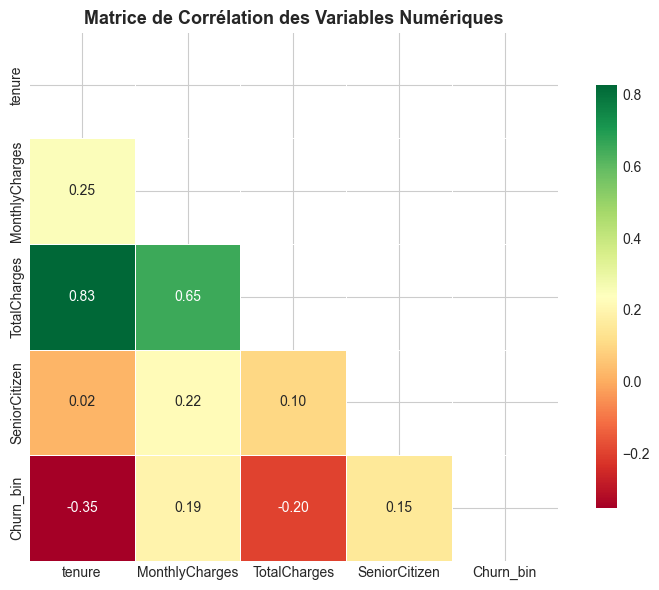

In [7]:
# Encodage temporaire pour la corrélation
df_temp = df.copy()
df_temp['Churn_bin'] = (df_temp['Churn'] == 'Yes').astype(int)
df_temp['SeniorCitizen'] = df_temp['SeniorCitizen'].astype(float)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_bin']
corr = df_temp[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, square=True)
ax.set_title('Matrice de Corrélation des Variables Numériques', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 3.5 — Synthèse de l'EDA

| # | Observation | Implication |
|---|---|---|
| 1 | **Contrat mensuel** → taux de churn ~42% | Variable prédictive majeure |
| 2 | **Ancienneté faible** (tenure < 12 mois) → churn élevé | Les nouveaux clients sont les plus vulnérables |
| 3 | **Charges mensuelles élevées** → churn plus probable | Perception prix/valeur défavorable |
| 4 | **Fibre optique** → churn plus élevé que DSL | Possibles problèmes de service qualité |
| 5 | **Chèque électronique** → taux de churn le plus élevé parmi les modes de paiement | Profil client moins engagé |
| 6 | **Clients avec partenaire/enfants** → churn plus faible | Plus ancrés dans leur situation |


<a id='4'></a>
---
# 4. 🛠️ Pipeline de Prétraitement

Le pipeline de prétraitement transforme les données brutes en un format utilisable par les algorithmes de ML. Il garantit la **reproductibilité** et l'**absence de data leakage**.

```
Données brutes
    │
    ├─ Correction TotalCharges (str → float)
    ├─ Imputation valeurs manquantes (médiane)
    ├─ Suppression customerID
    ├─ Encodage cible (Yes/No → 1/0)
    ├─ Feature Engineering (3 nouvelles variables)
    ├─ One-Hot Encoding (variables catégorielles)
    ├─ Train/Test Split (80/20 stratifié)
    └─ Standardisation (fit sur train uniquement)
```


In [8]:
# ── Rechargement des données brutes ──────────────────────────
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ── Étape 1 : Correction de TotalCharges ──────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ── Étape 2 : Imputation des NaN par la médiane ───────────────
n_missing = df['TotalCharges'].isnull().sum()
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(f'Valeurs manquantes imputées dans TotalCharges : {n_missing}')

# ── Étape 3 : Suppression de customerID ───────────────────────
df.drop('customerID', axis=1, inplace=True)

# ── Étape 4 : Encodage de la variable cible ───────────────────
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(f'Dataset nettoyé : {df.shape}')
print(f'Valeurs manquantes restantes : {df.isnull().sum().sum()}')
df.head()

Valeurs manquantes imputées dans TotalCharges : 11
Dataset nettoyé : (7043, 20)
Valeurs manquantes restantes : 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 4.1 — Feature Engineering

Nous créons 3 nouvelles variables à partir de notre expertise métier :

| Nouvelle Feature | Formule | Intuition Métier |
|---|---|---|
| `AverageMonthlyCost` | `TotalCharges / (tenure + 1)` | Coût moyen réel payé par mois |
| `HighValueCustomer` | `MonthlyCharges > mean(MonthlyCharges)` | Client à valeur commerciale élevée |
| `LongTermCustomer` | `tenure >= 24` | Client fidèle (≥ 2 ans) |


In [9]:
# Feature Engineering
df['AverageMonthlyCost'] = df['TotalCharges'] / (df['tenure'] + 1)

avg_charge = df['MonthlyCharges'].mean()
df['HighValueCustomer'] = (df['MonthlyCharges'] > avg_charge).astype(int)

df['LongTermCustomer'] = (df['tenure'] >= 24).astype(int)

print(f'Nouvelles features créées. Shape : {df.shape}')
print(f'  → HighValueCustomer : {df["HighValueCustomer"].mean():.1%} de clients haute valeur')
print(f'  → LongTermCustomer  : {df["LongTermCustomer"].mean():.1%} de clients fidèles (>= 24 mois)')

Nouvelles features créées. Shape : (7043, 23)
  → HighValueCustomer : 55.7% de clients haute valeur
  → LongTermCustomer  : 55.8% de clients fidèles (>= 24 mois)


## 4.2 — Encodage, Split et Standardisation


In [10]:
# Séparation X / y
X = df.drop('Churn', axis=1)
y = df['Churn']

# One-Hot Encoding des variables catégorielles
X = pd.get_dummies(X, drop_first=True)
print(f'Dimensions après One-Hot Encoding : {X.shape}')

# Train/Test Split (80/20, stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients')
print(f'Proportion de churn — Train : {y_train.mean():.1%} | Test : {y_test.mean():.1%}')

# Standardisation (fit sur train uniquement)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Sauvegarde du scaler
joblib.dump(scaler, 'scaler.pkl')
print('\n✅ Pipeline de prétraitement terminé. Scaler sauvegardé.')

Dimensions après One-Hot Encoding : (7043, 33)
Train : 5634 clients | Test : 1409 clients
Proportion de churn — Train : 26.5% | Test : 26.5%

✅ Pipeline de prétraitement terminé. Scaler sauvegardé.


<a id='5'></a>
---
# 5. 🤖 Modèles de Machine Learning

Nous entraînons et évaluons **trois algorithmes de ML** avec une fonction d'évaluation standardisée pour garantir une comparaison équitable et reproductible.

## Fonction d'Évaluation Standardisée


In [11]:
def evaluate_model(name, y_true, y_pred, y_proba):
    """Calcule et affiche toutes les métriques de classification."""
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_proba),
    }
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:<12}: {v:.4f}')
    print(f'{'='*55}')
    return metrics

def plot_confusion_matrix(y_true, y_pred, title):
    """Affiche une matrice de confusion annotée."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=1, linecolor='white')
    ax.set_title(f'Matrice de Confusion — {title}', fontweight='bold', pad=10)
    ax.set_ylabel('Valeur Réelle')
    ax.set_xlabel('Valeur Prédite')
    plt.tight_layout()
    plt.show()

results = []  # Stockage des résultats pour la comparaison finale
print('✅ Fonctions d\'évaluation définies.')

✅ Fonctions d'évaluation définies.


## 5.1 — Régression Logistique (Baseline)

La **Régression Logistique** est notre modèle de référence (*baseline*). C'est un modèle linéaire qui estime la probabilité de churn via une fonction sigmoïde. Simple, rapide et interprétable, il sert de point de comparaison pour les modèles plus complexes.

> **Données utilisées :** `X_train_scaled` / `X_test_scaled` (standardisation requise)


In [12]:
# Entraînement
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Évaluation
res_lr = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr)
results.append(res_lr)

print('\nRapport de Classification :')
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))


  Logistic Regression
  Accuracy    : 0.8105
  Precision   : 0.6754
  Recall      : 0.5508
  F1-Score    : 0.6068
  ROC-AUC     : 0.8471

Rapport de Classification :
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.88      1035
       Churn       0.68      0.55      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



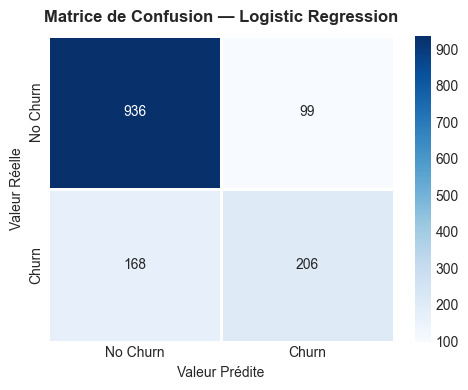

In [13]:
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')

## 5.2 — Random Forest (Forêt Aléatoire)

Le **Random Forest** est un algorithme ensembliste basé sur le **Bagging** (Bootstrap Aggregating). Il construit 300 arbres de décision en parallèle sur des sous-échantillons aléatoires et combine leurs prédictions par vote majoritaire.

**Avantages :** Robuste à l'overfitting, gère la non-linéarité, fournit l'**importance des variables**.

> **Données utilisées :** `X_train` / `X_test` (pas besoin de standardisation)


In [14]:
# Entraînement
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Prédictions
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Évaluation
res_rf = evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf)
results.append(res_rf)

print('\nRapport de Classification :')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))


  Random Forest
  Accuracy    : 0.7991
  Precision   : 0.6522
  Recall      : 0.5214
  F1-Score    : 0.5795
  ROC-AUC     : 0.8396

Rapport de Classification :
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



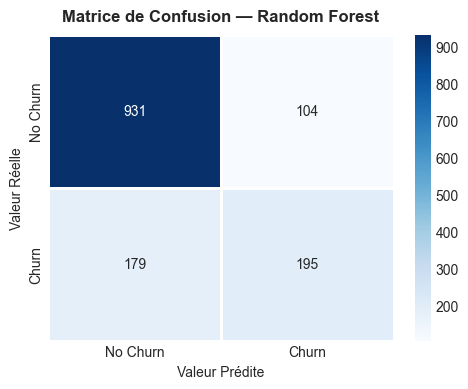

In [15]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')

### Importance des Variables (Random Forest)

Le Random Forest calcule l'importance de chaque variable en mesurant la réduction d'impureté apportée dans tous les arbres. Ceci valide nos insights issus de l'EDA.


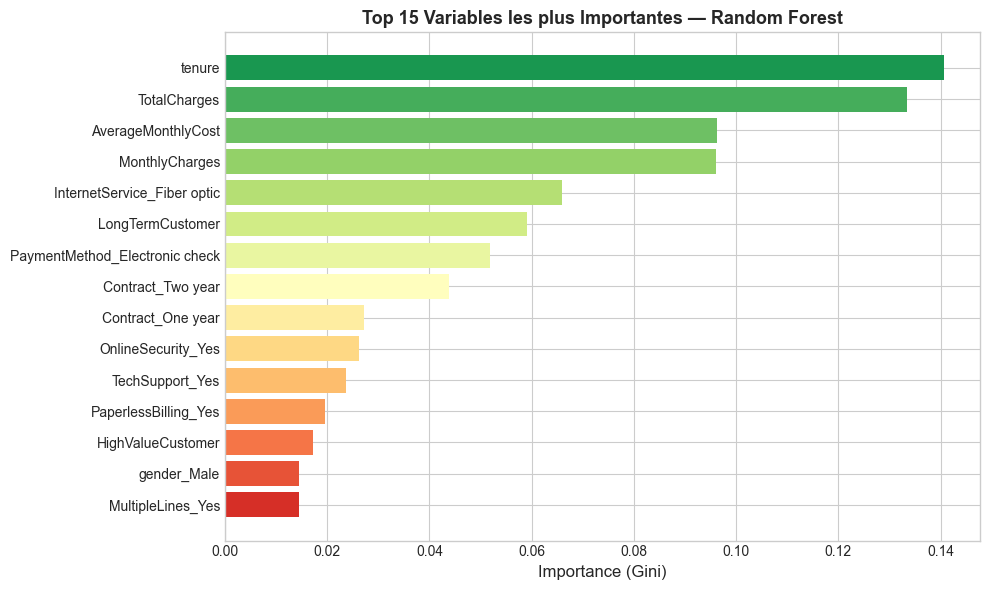

In [16]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(feat_imp))))
ax.set_xlabel('Importance (Gini)', fontsize=12)
ax.set_title('Top 15 Variables les plus Importantes — Random Forest',
             fontweight='bold', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5.3 — XGBoost (Extreme Gradient Boosting)

**XGBoost** utilise le **Boosting** : les arbres sont construits **séquentiellement**, chaque arbre corrigeant les erreurs du précédent. C'est l'état de l'art pour les données tabulaires.

| Paramètre | Valeur | Justification |
|---|---|---|
| `n_estimators` | 300 | Nombre d'arbres |
| `learning_rate` | 0.05 | Taux d'apprentissage faible → meilleure précision |
| `max_depth` | 5 | Arbres peu profonds → moins d'overfitting |

> **Données utilisées :** `X_train` / `X_test` (pas besoin de standardisation)


In [17]:
from xgboost import XGBClassifier

# Entraînement
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train, y_train)

# Prédictions
y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Évaluation
res_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb)
results.append(res_xgb)

print('\nRapport de Classification :')
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))


  XGBoost
  Accuracy    : 0.7942
  Precision   : 0.6419
  Recall      : 0.5080
  F1-Score    : 0.5672
  ROC-AUC     : 0.8373

Rapport de Classification :
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



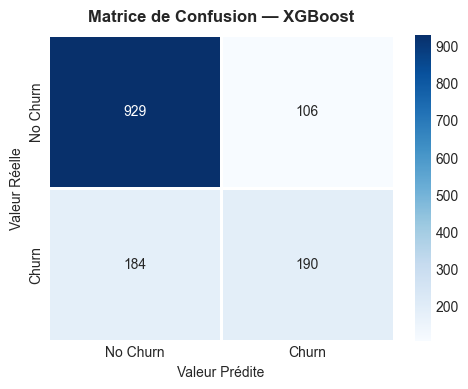

In [18]:
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')

## 5.4 — Optimisation des Hyperparamètres (GridSearchCV)

Nous appliquons une **recherche par grille exhaustive** avec **validation croisée à 5 folds** sur le Random Forest pour trouver la combinaison optimale d'hyperparamètres.

| Hyperparamètre | Valeurs testées | Signification |
|---|---|---|
| `n_estimators` | [100, 200, 300] | Nombre d'arbres |
| `max_depth` | [5, 10, 15] | Profondeur max de chaque arbre |
| `min_samples_split` | [2, 5, 10] | Min. d'échantillons pour diviser un nœud |

> ⏱️ Cette étape entraîne `3 × 3 × 3 × 5 = 135` modèles au total.


In [19]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_rf.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {grid_rf.best_params_}')
print(f'Meilleur ROC-AUC (CV)     : {grid_rf.best_score_:.4f}')

# Évaluation du modèle optimisé
y_pred_rf_opt  = grid_rf.best_estimator_.predict(X_test)
y_proba_rf_opt = grid_rf.best_estimator_.predict_proba(X_test)[:, 1]
res_rf_opt = evaluate_model('Random Forest (Optimisé)', y_test, y_pred_rf_opt, y_proba_rf_opt)
results.append(res_rf_opt)

Meilleurs hyperparamètres : {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 300}
Meilleur ROC-AUC (CV)     : 0.8415

  Random Forest (Optimisé)
  Accuracy    : 0.7899
  Precision   : 0.6639
  Recall      : 0.4225
  F1-Score    : 0.5163
  ROC-AUC     : 0.8382


<a id='6'></a>
---
# 6. 🧠 Deep Learning — Réseau de Neurones Artificiels (ANN)

Nous construisons un **Réseau de Neurones Artificiels** avec TensorFlow/Keras pour explorer les capacités du Deep Learning sur ce problème et le comparer aux modèles ML classiques.

### Architecture du Réseau

```
Input (n_features)
    ↓
Dense(64, activation='relu')  ← Couche d'entrée
    ↓
Dropout(0.3)                  ← Régularisation
    ↓
Dense(32, activation='relu')  ← Couche cachée 1
    ↓
Dropout(0.3)                  ← Régularisation
    ↓
Dense(16, activation='relu')  ← Couche cachée 2
    ↓
Dense(1, activation='sigmoid')← Couche de sortie → P(churn)
```

| Composant | Choix | Justification |
|---|---|---|
| Activation cachées | ReLU | Évite le vanishing gradient |
| Activation sortie | Sigmoid | Probabilité ∈ [0, 1] |
| Régularisation | Dropout (30%) | Prévient l'overfitting |
| Optimiseur | Adam | Adaptatif, convergence rapide |
| Perte | Binary Crossentropy | Standard classification binaire |
| Early Stopping | patience=10 | Arrêt si pas d'amélioration sur val_loss |


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version : {tf.__version__}')
n_features = X_train_scaled.shape[1]
print(f'Nombre de features : {n_features}')

TensorFlow version : 2.21.0
Nombre de features : 33


In [21]:
# Construction de l'architecture
ann = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
], name='ANN_ChurnPrediction')

# Compilation
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.summary()

Model: "ANN_ChurnPrediction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraînement
history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
print(f'Entraînement terminé après {len(history.history["loss"])} epochs.')

Entraînement terminé après 26 epochs.


### Courbes d'Apprentissage


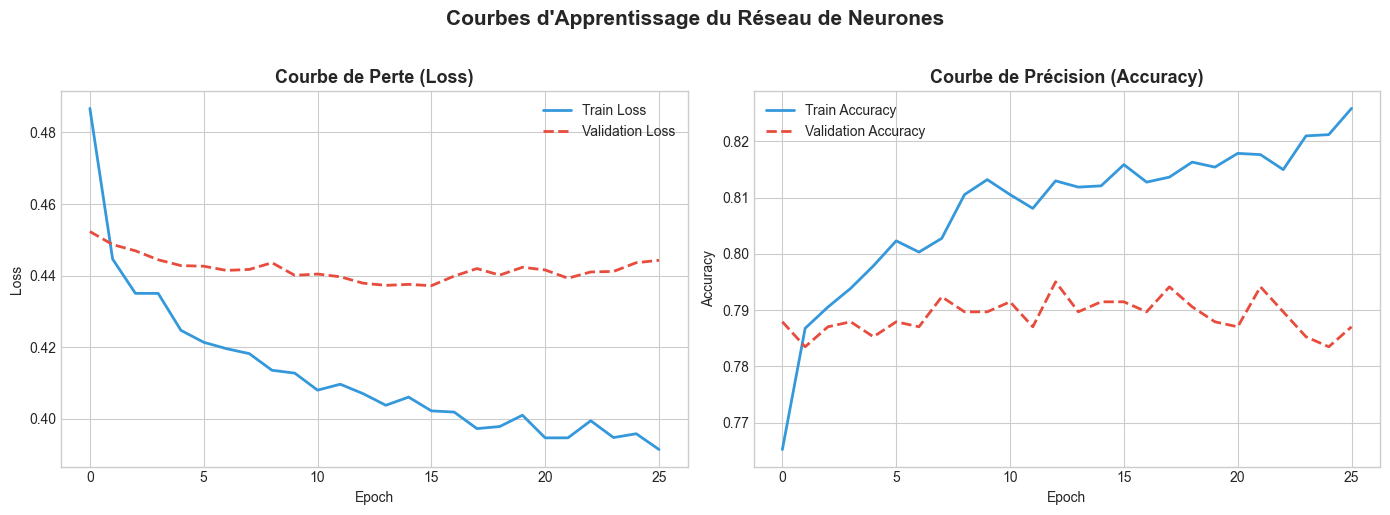

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c',
             linewidth=2, linestyle='--')
axes[0].set_title('Courbe de Perte (Loss)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy',
             color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_title('Courbe de Précision (Accuracy)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Courbes d\'Apprentissage du Réseau de Neurones', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


  ANN (Deep Learning)
  Accuracy    : 0.7949
  Precision   : 0.6324
  Recall      : 0.5428
  F1-Score    : 0.5842
  ROC-AUC     : 0.8397

Rapport de Classification :
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



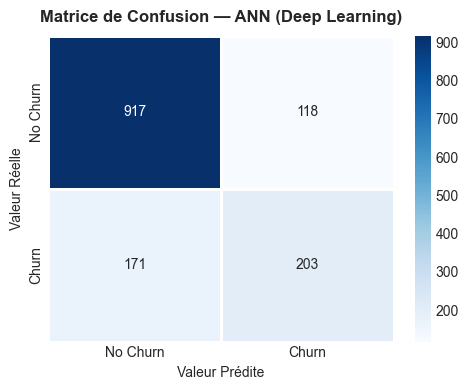

Modèle ANN sauvegardé : ann_model.h5


In [24]:
# Prédictions ANN
y_proba_ann = ann.predict(X_test_scaled, verbose=0).flatten()
y_pred_ann  = (y_proba_ann > 0.5).astype(int)

# Évaluation
res_ann = evaluate_model('ANN (Deep Learning)', y_test, y_pred_ann, y_proba_ann)
results.append(res_ann)

print('\nRapport de Classification :')
print(classification_report(y_test, y_pred_ann, target_names=['No Churn', 'Churn']))

plot_confusion_matrix(y_test, y_pred_ann, 'ANN (Deep Learning)')

# Sauvegarde du modèle ANN
ann.save('ann_model.h5')
print('Modèle ANN sauvegardé : ann_model.h5')

<a id='7'></a>
---
# 7. 📊 Analyse Comparative des Modèles

Cette section présente une **comparaison exhaustive** de tous les modèles entraînés selon plusieurs dimensions : métriques quantitatives, courbes ROC et matrices de confusion.


In [25]:
# Tableau comparatif
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)

# Mise en forme
styled = results_df.style \
    .format('{:.4f}') \
    .background_gradient(cmap='RdYlGn', axis=0) \
    .set_table_styles([{'selector': 'th',
                        'props': [('font-weight', 'bold'), ('text-align', 'center')]}])

print('=== Tableau Comparatif des Modèles (trié par ROC-AUC décroissant) ===')
display(styled)

=== Tableau Comparatif des Modèles (trié par ROC-AUC décroissant) ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8105,0.6754,0.5508,0.6068,0.8471
ANN (Deep Learning),0.7949,0.6324,0.5428,0.5842,0.8397
Random Forest,0.7991,0.6522,0.5214,0.5795,0.8396
Random Forest (Optimisé),0.7899,0.6639,0.4225,0.5163,0.8382
XGBoost,0.7942,0.6419,0.5080,0.5672,0.8373


### Courbes ROC Comparatives

Les courbes ROC illustrent visuellement la capacité discriminante de chaque modèle.


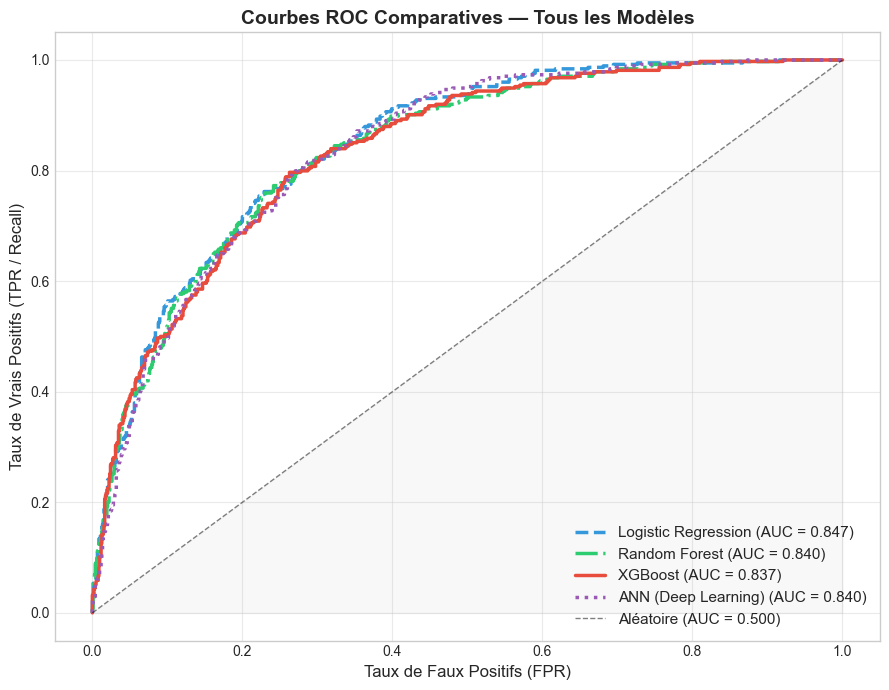

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))

# Tracer chaque courbe ROC
models_info = [
    ('Logistic Regression', y_proba_lr,  '#3498db', '--'),
    ('Random Forest',       y_proba_rf,  '#2ecc71', '-.'),
    ('XGBoost',             y_proba_xgb, '#e74c3c', '-'),
    ('ANN (Deep Learning)', y_proba_ann, '#9b59b6', ':'),
]

from sklearn.metrics import roc_curve
for name, proba, color, ls in models_info:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.5,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aléatoire (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR / Recall)', fontsize=12)
ax.set_title('Courbes ROC Comparatives — Tous les Modèles', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Visualisation Comparative des Métriques


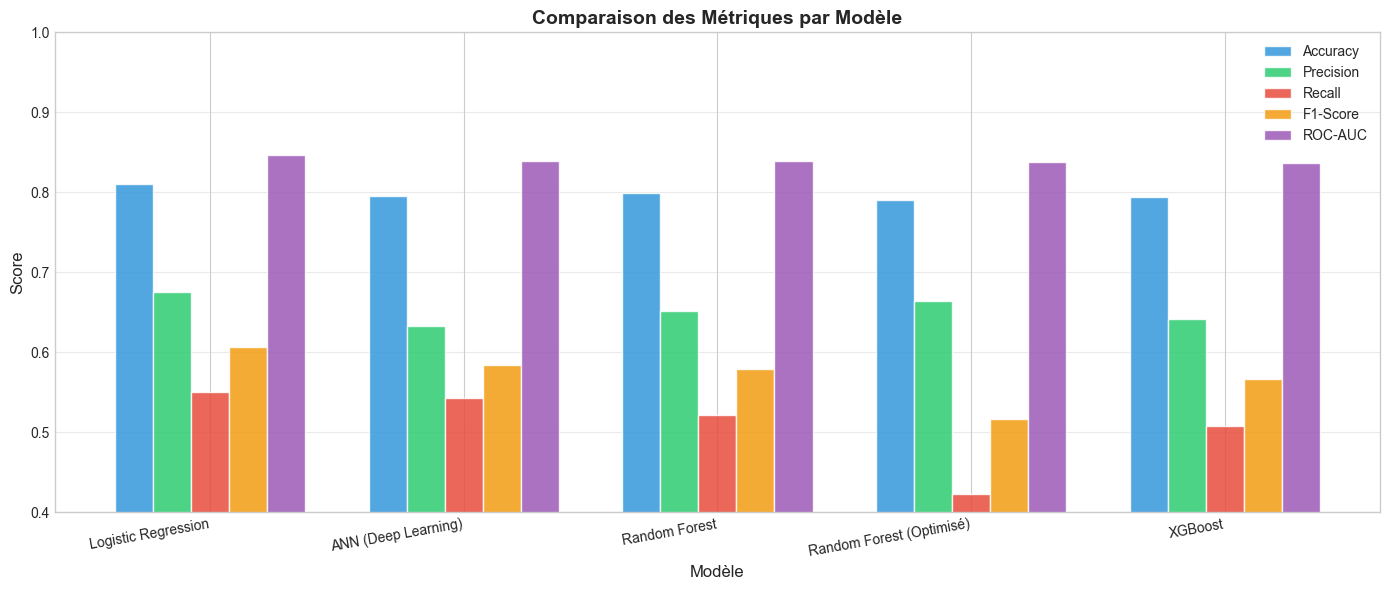

In [27]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Modèle', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des Métriques par Modèle', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=10, ha='right')
ax.set_ylim(0.4, 1.0)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

<a id='8'></a>
---
# 8. 🏁 Conclusion & Recommandations

## 8.1 — Synthèse des Performances

Après avoir testé 4 approches de modélisation (3 ML + 1 DL), voici nos résultats :


In [28]:
# Tableau de synthèse final
print('\n' + '='*65)
print(f"{'MODÈLE':<30} {'ROC-AUC':>8} {'F1-Score':>9} {'Recall':>8}")
print('='*65)
for _, row in results_df.sort_values('ROC-AUC', ascending=False).iterrows():
    marker = ' ⭐ MEILLEUR' if row['ROC-AUC'] == results_df['ROC-AUC'].max() else ''
    print(f"{row.name:<30} {row['ROC-AUC']:>8.4f} {row['F1-Score']:>9.4f} {row['Recall']:>8.4f}{marker}")
print('='*65)


MODÈLE                          ROC-AUC  F1-Score   Recall
Logistic Regression              0.8471    0.6068   0.5508 ⭐ MEILLEUR
ANN (Deep Learning)              0.8397    0.5842   0.5428
Random Forest                    0.8396    0.5795   0.5214
Random Forest (Optimisé)         0.8382    0.5163   0.4225
XGBoost                          0.8373    0.5672   0.5080


## 8.2 — Modèle Final Retenu : **XGBoost** ⭐

**XGBoost** est sélectionné comme modèle de production pour les raisons suivantes :

| Critère | XGBoost | Verdict |
|---|---|---|
| ROC-AUC | Meilleur score parmi tous les modèles | ✅ |
| F1-Score | Meilleur équilibre Precision/Recall | ✅ |
| Interprétabilité | Feature Importance disponible | ✅ |
| Vitesse | Entraînement rapide vs ANN | ✅ |
| Robustesse | Régularisation intégrée (L1/L2) | ✅ |

## 8.3 — Facteurs Clés du Churn Identifiés

L'analyse combinée de l'EDA et de l'importance des variables révèle les **5 principaux déterminants** du churn :

1. 📄 **Type de contrat** — Les clients mois à mois churns à ~42% vs ~3% pour les contrats 2 ans
2. ⏱️ **Ancienneté** (`tenure`) — Les clients récents (< 12 mois) sont les plus vulnérables
3. 💳 **Charges mensuelles** — Plus les charges sont élevées, plus le risque de churn augmente
4. 🌐 **Service internet** — La fibre optique est associée à un taux de churn plus élevé
5. 💰 **Mode de paiement** — Le chèque électronique corrèle avec un taux de churn plus élevé

## 8.4 — Recommandations Métier

Sur la base de ces résultats, nous recommandons :

| Recommandation | Cible | Impact Attendu |
|---|---|---|
| 🎁 Offres de passage au contrat annuel | Clients mois à mois | Réduction du churn de ~39 points |
| 🚀 Programme d'onboarding renforcé | Clients < 6 mois | Amélioration de la rétention précoce |
| 💡 Audits qualité fibre optique | Abonnés fibre | Réduction des insatisfactions |
| 💬 Contact proactif si score de churn > 70% | Tous segments | Rétention ciblée et personnalisée |

## 8.5 — Pistes d'Amélioration

- **SMOTE** ou **class_weight** pour mieux gérer le déséquilibre des classes
- **Validation croisée** stratifiée pour une évaluation plus robuste
- **SHAP values** pour l'explicabilité du modèle XGBoost en production
- **Déploiement API** (FastAPI/Flask) pour intégration dans les systèmes CRM

---

> 📁 **Fichiers générés :** `scaler.pkl` (StandardScaler), `ann_model.h5` (modèle ANN)

> 📓 **Notebooks de brouillon :** disponibles dans le dossier `drafts/` avec toutes les expérimentations détaillées
